# 데이터 불러오기

In [1]:
import os
import random
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# import warnings
# warnings.filterwarnings("ignore")

import seaborn as sns

import matplotlib.pyplot as plt
%matplotlib inline

from tqdm.auto import tqdm
from IPython.display import display

base_path = './'
data_path = os.path.join(base_path, 'data/')
users = pd.read_csv(data_path+'users.csv')

# 기초 정보

In [2]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68092 entries, 0 to 68091
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   68092 non-null  int64  
 1   location  68092 non-null  object 
 2   age       40259 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.6+ MB


In [3]:
users.head(10)

,user_id,location,age
0,8,"timmins, ontario, canada",NaN
1,11400,"ottawa, ontario, canada",49.0
2,11676,"n/a, n/a, n/a",NaN
3,67544,"toronto, ontario, canada",30.0
4,85526,"victoria, british columbia, canada",36.0
5,96054,"ottawa, ontario, canada",29.0
6,116866,"ottawa, ,",NaN
7,123629,"kingston, ontario, canada",NaN
8,177458,"ottawa, ontario, canada",29.0
9,200273,"comber, ontario, canada",NaN


# ID

## 중복 검사

In [4]:
users['user_id'].duplicated().sum()

np.int64(0)

# Location 

## 정보 검사

In [5]:
def count_valid_info(loc):
    if pd.isna(loc):
        return 0
    
    parts = loc.split(',')
    
    valid_count = 0
    for part in parts:
        clean_part = part.lower().strip()
        if clean_part != '' and clean_part != 'n/a':
            valid_count += 1
            
    return valid_count

users['valid_count'] = users['location'].apply(count_valid_info)

summary = users['valid_count'].value_counts().sort_index()
total_count = len(users)
summary_df = pd.DataFrame({
    'Count': summary,
    'Ratio (%)': (summary / total_count) * 100
})

print("=== 유효 정보 개수별 분포 ===")
print(summary_df)
print("\n")




=== 유효 정보 개수별 분포 ===
             Count  Ratio (%)
valid_count                  
0                8   0.011749
1             1535   2.254303
2             2210   3.245609
3            64135  94.188745
4              196   0.287846
5                8   0.011749




각 케이스별 데이터 예시 확인

In [6]:
for count in range(6): 
    print(f"--- 정보가 {count}개인 경우 ---")
    subset = users[users['valid_count'] == count]
    if not subset.empty:
        print(subset[['location']])
    else:
        print("(해당 데이터 없음)")
    print()


--- 정보가 0개인 경우 ---
            location
2      n/a, n/a, n/a
1679       n/a, n/a,
7760   n/a, n/a, n/a
8634             , ,
38772      n/a, n/a,
48206         n/a, ,
58435            , ,
67104      n/a, n/a,

--- 정보가 1개인 경우 ---
             location
6           ottawa, ,
32         seattle, ,
49     albuquerque, ,
72          humble, ,
120          aloha, ,
...               ...
67711   brockville, ,
67776       milano, ,
67929      houston, ,
67930    sammamish, ,
68058      calgary, ,

[1535 rows x 1 columns]

--- 정보가 2개인 경우 ---
                               location
143                    pearland, texas,
273    west springfield, massachusetts,
633                  malmok, n/a, aruba
651                   vigo, pontevedra,
720           singapore, n/a, singapore
...                                 ...
68052          zürich, n/a, switzerland
68063         singapore, n/a, singapore
68064              rijeka, n/a, croatia
68068                   bolligen, bern,
68075               mun

## 정보가 1개인 경우

In [7]:
# 1. 정보가 딱 1개인 데이터만 추출
target_users = users[users['valid_count'] == 1].copy()

# 2. 유효한 정보의 위치(Index)를 찾는 함수 정의
def find_valid_index(loc):
    if pd.isna(loc):
        return -1
    
    parts = loc.split(',')
    
    for idx, part in enumerate(parts):
        clean_part = part.lower().strip()
        # 유효한 정보의 정의 (기존 로직과 동일)
        if clean_part != '' and clean_part != 'n/a':
            return idx # 발견 즉시 해당 인덱스 반환
            
    return -1 # 없을 경우 (이론상 valid_count=1이므로 발생 안 함)

# 3. 위치 정보 추출 적용
target_users['valid_position_idx'] = target_users['location'].apply(find_valid_index)

# 4. 개수 및 비율 계산
pos_counts = target_users['valid_position_idx'].value_counts().sort_index()
total_target = len(target_users)

pos_summary = pd.DataFrame({
    'Count': pos_counts,
    'Ratio (%)': (pos_counts / total_target * 100).round(2)
})

# 인덱스를 이해하기 쉽게 라벨링 (0 -> 첫번째, 1 -> 두번째 ...)
# 데이터에 따라 인덱스가 더 늘어날 수 있으므로 동적으로 라벨링하거나 매핑
index_labels = {
    0: '첫번째 위치 (Index 0)',
    1: '두번째 위치 (Index 1)',
    2: '세번째 위치 (Index 2)',
    3: '네번째 위치 (Index 3)',
    4: '다섯번째 위치 (Index 4)'
}
pos_summary.index = pos_summary.index.map(lambda x: index_labels.get(x, f'{x+1}번째 위치 (Index {x})'))

# 5. 결과 출력
print(f"=== 정보가 1개인 데이터({total_target}건)의 위치별 분포 ===")
print(pos_summary)
print("\n")



=== 정보가 1개인 데이터(1535건)의 위치별 분포 ===
                    Count  Ratio (%)
valid_position_idx                  
첫번째 위치 (Index 0)     1489      97.00
두번째 위치 (Index 1)        2       0.13
세번째 위치 (Index 2)       44       2.87




In [8]:
# 각 위치별 실제 데이터 예시 확인
unique_indices = sorted(target_users['valid_position_idx'].unique())
for idx in unique_indices:
    label = index_labels.get(idx, f'{idx+1}번째 위치')
    print(f"--- {label}에 정보가 있는 경우 ---")
    
    # 해당 인덱스인 데이터 5개만 추출해서 확인
    example_subset = target_users[target_users['valid_position_idx'] == idx]['location'].head(5)
    for loc in example_subset:
        print(f"Original: [{loc}]")
    print()

--- 첫번째 위치 (Index 0)에 정보가 있는 경우 ---
Original: [ottawa, ,]
Original: [seattle, ,]
Original: [albuquerque, ,]
Original: [humble, ,]
Original: [aloha, ,]

--- 두번째 위치 (Index 1)에 정보가 있는 경우 ---
Original: [n/a, california,]
Original: [, usa,]

--- 세번째 위치 (Index 2)에 정보가 있는 경우 ---
Original: [n/a, n/a, united kingdom]
Original: [n/a, n/a, usa]
Original: [n/a, n/a, singapore]
Original: [n/a, n/a, singapore]
Original: [n/a, n/a, usa]



## 국가 분포 검사

In [9]:
users['country_extracted'] = users['location'].str.split(',').str[-1].str.strip()

# 데이터 정제
# 빈 문자열이나 'n/a' 등을 제외하고 싶다면 아래 코드를 활용.
# df = df[~df['country_extracted'].isin(['', 'n/a'])]

# 4. 국가별 분포 확인 (상위 20개)
country_counts = users['country_extracted'].value_counts().head(20)

total_users = len(users)
dist_df = pd.DataFrame({
    'Count': country_counts,
    'Ratio (%)': (country_counts / total_users * 100).round(2) # 소수점 둘째 자리까지
})
print("=== 상위 20개 국가 분포 (개수 및 비율) ===")
print(dist_df)

=== 상위 20개 국가 분포 (개수 및 비율) ===
                   Count  Ratio (%)
country_extracted                  
usa                44135      64.82
canada              6239       9.16
germany             3528       5.18
united kingdom      2956       4.34
                    2100       3.08
australia           1801       2.64
spain               1661       2.44
france               796       1.17
italy                773       1.14
new zealand          454       0.67
switzerland          451       0.66
netherlands          404       0.59
portugal             327       0.48
austria              252       0.37
malaysia             170       0.25
singapore            129       0.19
sweden               120       0.18
ireland              109       0.16
belgium              104       0.15
brazil               103       0.15


# Age

## 결측치 검사

In [10]:
missing_count = users['age'].isnull().sum()
missing_ratio = (users['age'].isnull().sum() / len(users)) * 100

print(f"Age 컬럼의 결측치 개수: {missing_count}개")
print(f"Age 컬럼의 결측치 비율: {missing_ratio:.2f}%")

Age 컬럼의 결측치 개수: 27833개
Age 컬럼의 결측치 비율: 40.88%


## 분포 검사

In [11]:
users['age'].describe()

count    40259.000000
mean        36.069873
std         13.842571
min          5.000000
25%         25.000000
50%         34.000000
75%         45.000000
max         99.000000
Name: age, dtype: float64

분포 시각화

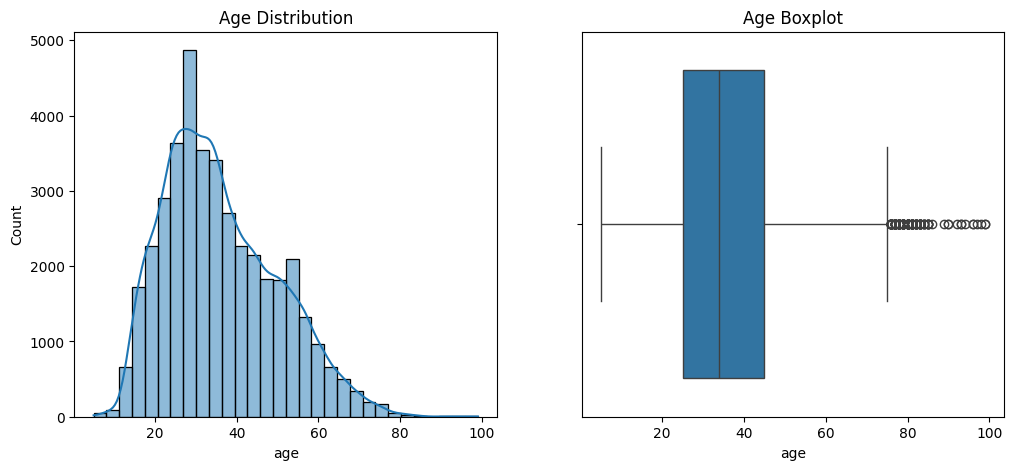

In [12]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(users['age'].dropna(), bins=30, kde=True)
plt.title('Age Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(x=users['age'])
plt.title('Age Boxplot')
plt.show()

## 10살 간격 관측

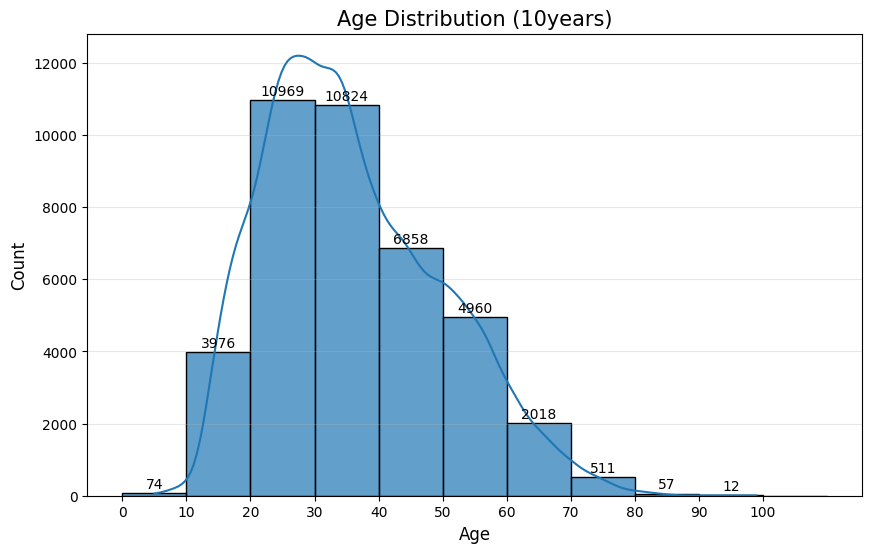

In [15]:
# 그래프 크기 설정 (하나만 그리니까 적당한 크기로)
plt.figure(figsize=(10, 6))

# 히스토그램 그리기
ax = sns.histplot(users['age'].dropna(), bins=range(0, 111, 10), kde=True, edgecolor='black', alpha=0.7)

# 제목 및 라벨 설정
plt.title('Age Distribution (10years)', fontsize=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)

# X축 눈금을 10단위로 고정 (0, 10, 20, ..., 100)
plt.xticks(np.arange(0, 101, 10))

# (선택사항) 각 막대 위에 실제 숫자 표시해주기 (분석할 때 편합니다)
for p in ax.patches:
    if p.get_height() > 0: # 데이터가 있는 막대만 표시
        ax.text(p.get_x() + p.get_width() / 2., p.get_height() + 50, 
                int(p.get_height()), 
                ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', alpha=0.3) # Y축 그리드 살짝 추가해서 높이 비교 쉽게
plt.show()